In [1]:
import os, joblib
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import root_mean_squared_error, r2_score

os.makedirs("../models", exist_ok=True)

TARGET = "cpi_headline_yoy"
PERSISTENCE = ["cpi_headline_yoy_lag1", "cpi_headline_yoy_lag12"]
MACRO = ["USA_CPI", "iip_general_yoy", "m3_money_supply_yoy", "rbi_repo_rate_yoy_diff"]
COMMODITY = ["wpi_primary_food_articles_yoy", "wpi_manufactured_food_yoy", "wpi_wheat_yoy", "wpi_rice_yoy", "wpi_maize_yoy", "wpi_gram_chana_yoy", "wpi_arhar_tur_yoy", "wpi_moong_yoy", "wpi_urad_yoy", "wpi_masur_yoy", "wpi_tomato_yoy", "wpi_onion_yoy", "wpi_potato_yoy", "wpi_brinjal_yoy", "wpi_cabbage_yoy", "wpi_garlic_yoy", "wpi_mustard_oil_yoy", "wpi_soybean_oil_yoy", "wpi_groundnut_oil_yoy", "wpi_milk_yoy", "wpi_egg_yoy", "wpi_sugar_yoy", "crude_oil_brent_usd_yoy", "palm_oil_usd_yoy", "global_fertilizer_index_yoy"]
CLIMATE = ["rainfall_total_mm", "rainfall_rate_mm_per_day", "temp_mean_celsius", "relative_humidity_2m_pct", "surface_soil_wetness_index", "wind_speed_10m_ms", "solar_irradiance_kwm2", "rainfall_total_mm_anom", "rainfall_rate_mm_per_day_anom", "temp_mean_celsius_anom", "relative_humidity_2m_pct_anom", "surface_soil_wetness_index_anom", "wind_speed_10m_ms_anom", "solar_irradiance_kwm2_anom"]

CONFIGS = {
    "Full": CLIMATE + MACRO + COMMODITY + PERSISTENCE,
    "Climate_only": CLIMATE + PERSISTENCE,
    "Macro_only": MACRO + PERSISTENCE,
    "Commodity_only": COMMODITY + PERSISTENCE
}


In [2]:
train_df = pd.read_csv("../data/train_processed.csv")
test_df = pd.read_csv("../data/test_processed.csv")

X_train, y_train = train_df.drop(columns=[TARGET]), train_df[TARGET]
X_test, y_test = test_df.drop(columns=[TARGET]), test_df[TARGET]


Training RandomForest: Full
Best Params: {'n_estimators': 500, 'min_samples_leaf': 2, 'max_features': 1.0, 'max_depth': 5}
TRAIN -> RMSE: 0.3750 | R2: 0.9835
TEST  -> RMSE: 0.8571  | R2: 0.7409


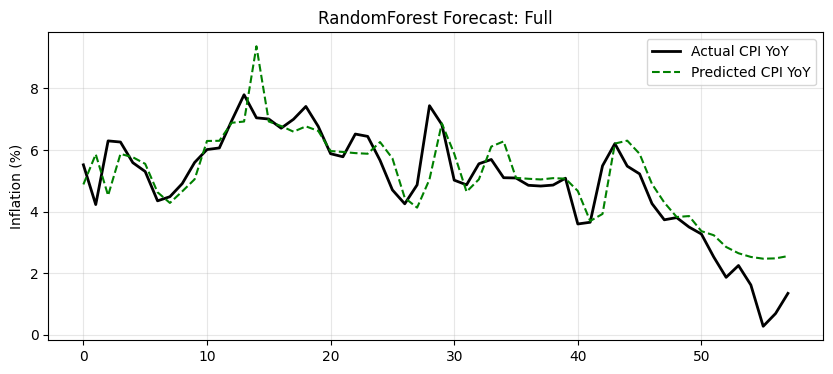


Training RandomForest: Climate_only
Best Params: {'n_estimators': 200, 'min_samples_leaf': 2, 'max_features': 1.0, 'max_depth': 3}
TRAIN -> RMSE: 0.6859 | R2: 0.9447
TEST  -> RMSE: 1.0206  | R2: 0.6326


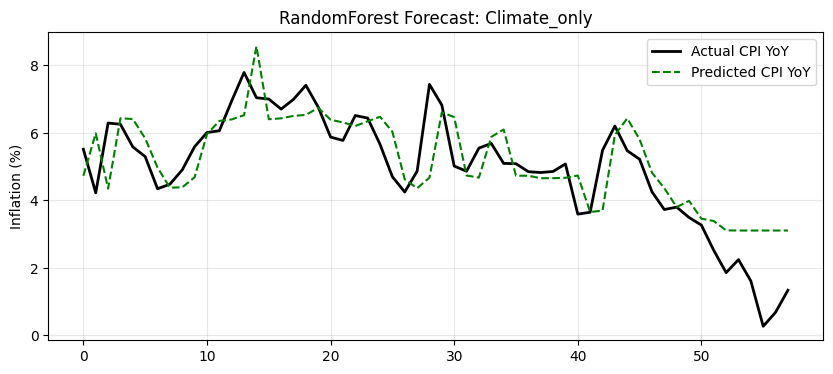


Training RandomForest: Macro_only
Best Params: {'n_estimators': 600, 'min_samples_leaf': 4, 'max_features': 1.0, 'max_depth': 7}
TRAIN -> RMSE: 0.5533 | R2: 0.9640
TEST  -> RMSE: 0.9193  | R2: 0.7019


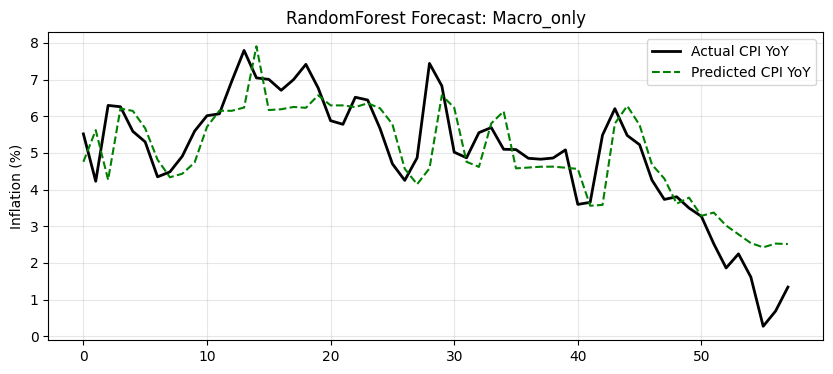


Training RandomForest: Commodity_only
Best Params: {'n_estimators': 200, 'min_samples_leaf': 2, 'max_features': 1.0, 'max_depth': 7}
TRAIN -> RMSE: 0.3076 | R2: 0.9889
TEST  -> RMSE: 0.8159  | R2: 0.7652


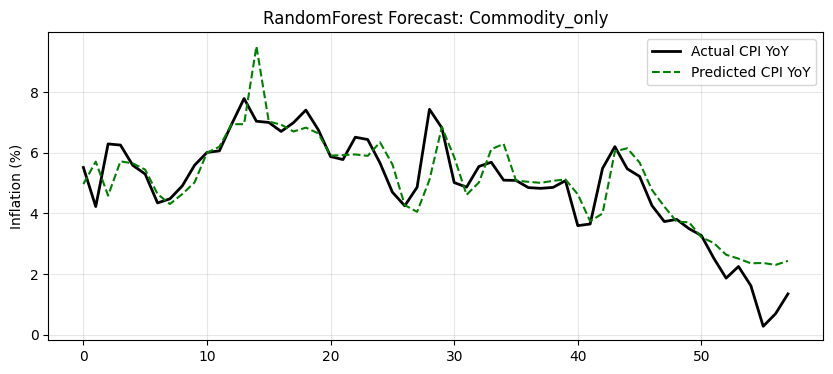

In [5]:
param_grid = {
    'n_estimators': [200, 300, 500, 600],
    'max_depth': [3, 5, 7],
    'min_samples_leaf': [2, 4, 8],
    'max_features': [0.3, 0.5, 0.7, 1.0]
}

tscv = TimeSeriesSplit(n_splits=5)

for config_name, features in CONFIGS.items():
    print(f"\n{'='*40}\nTraining RandomForest: {config_name}\n{'='*40}")
    X_tr_sub, X_te_sub = X_train[features], X_test[features]
    
    # 1. Tune & Train
    search = RandomizedSearchCV(RandomForestRegressor(random_state=42), param_distributions=param_grid, n_iter=100, cv=tscv, scoring='neg_root_mean_squared_error', random_state=42, n_jobs=-1)
    search.fit(X_tr_sub, y_train)
    best_model = search.best_estimator_
    
    # 2. Metrics
    y_tr_pred = best_model.predict(X_tr_sub)
    y_te_pred = best_model.predict(X_te_sub)
    
    print(f"Best Params: {search.best_params_}")
    print(f"TRAIN -> RMSE: {root_mean_squared_error(y_train, y_tr_pred):.4f} | R2: {r2_score(y_train, y_tr_pred):.4f}")
    print(f"TEST  -> RMSE: {root_mean_squared_error(y_test, y_te_pred):.4f}  | R2: {r2_score(y_test, y_te_pred):.4f}")
    
    # 3. Plot Forecast
    plt.figure(figsize=(10, 4))
    plt.plot(test_df["Date"] if "Date" in test_df else range(len(y_test)), y_test.values, label='Actual CPI YoY', color='black', linewidth=2)
    plt.plot(test_df["Date"] if "Date" in test_df else range(len(y_test)), y_te_pred, label='Predicted CPI YoY', color='green', linestyle='--')
    plt.title(f"RandomForest Forecast: {config_name}")
    plt.ylabel("Inflation (%)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # 4. Save Artifact
    joblib.dump(best_model, f"../models/RandomForest_{config_name}.joblib")